In [20]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
import scienceplots
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib as mpl
import numpy as np
import os    

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

plt.style.use(['science', 'ieee'])
con = duckdb.connect(database = 'results.db', read_only = True)

output = widgets.Output()

plt.rcParams.update({'font.size': 18})
plt.rcParams['axes.prop_cycle'] = mpl.cycler('linestyle', ['-', '--', ':', '-.']) + mpl.cycler('color', ['b', 'r', 'g', 'm'])

In [24]:
def plot_virsh(exp):
    query = f"""
    SELECT TIME, 
        AVG("VIRSH ACTUAL") as "VIRSH ACTUAL",
        AVG("VIRSH AVAILABLE") as "VIRSH AVAILABLE",
        AVG("VIRSH USABLE") AS "VIRSH USABLE",
    FROM virsh_stats 
    WHERE exp_name='{exp}' 
    GROUP BY TIME 
    ORDER BY TIME
    """
    df = con.execute(query).pl()
    
    fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
    
    ax.plot(df["TIME"]/1000, df["VIRSH ACTUAL"]/(1024), label="actual", color='g', linewidth=1)
    ax.plot(df["TIME"]/1000, df["VIRSH AVAILABLE"]/(1024), label="available", color='b', linewidth=1)
    ax.plot(df["TIME"]/1000, df["VIRSH USABLE"]/(1024), label="usable", color='m', linewidth=1)
    ax.plot(df["TIME"]/1000, (df["VIRSH ACTUAL"] - df["VIRSH USABLE"])/(1024), label="used", color='r', linewidth=1)
    
    ax.set_xlabel('Time (s)', fontweight='bold')
    ax.set_ylabel('Memory (MiB)', fontweight='bold')
    
    ax.legend(frameon=True)
    
    plt.tight_layout()
    plt.show()

def plot_cgroups(exp):
    query = f"""
    SELECT TIME, AVG("MEMORY CURRENT") AS "MEMORY CURRENT", AVG("SWAP CURRENT") AS "SWAP CURRENT" 
    FROM cgroup_stats 
    WHERE exp_name='{exp}' 
    GROUP BY TIME 
    ORDER BY TIME;
    """
    df = con.execute(query).pl()
    
    fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
    
    ax.plot(df["TIME"]/1000, df["MEMORY CURRENT"] / (1024*1024), label="memory.current", color='b', linewidth=1)
    ax.plot(df["TIME"]/1000, df["SWAP CURRENT"], label="swap.current", color='r', linewidth=1)
    
    ax.set_xlabel('Time (s)', fontweight='bold')
    ax.set_ylabel('Memory (MiB)', fontweight='bold')
    
    ax.legend(frameon=True)
    
    plt.tight_layout()
    plt.show()

def plot_cgroup_lists(exp):
    query = f"""
    SELECT TIME, 
        AVG("ACTIVE ANON")/(1024*1024) AS "ACTIVE ANON", 
        AVG("INACTIVE ANON") AS "INACTIVE ANON",
        AVG("ACTIVE FILE") AS "ACTIVE FILE",
        AVG("INACTIVE FILE") AS "INACTIVE FILE",
    FROM cgroup_stats 
    WHERE exp_name='{exp}' 
    GROUP BY TIME 
    ORDER BY TIME;
    """
    df = con.execute(query).pl()
    
    fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
    
    ax.plot(df["TIME"]/1000, df["ACTIVE ANON"], label="active anon", color='b', linewidth=1)
    ax.plot(df["TIME"]/1000, df["INACTIVE ANON"] / (1024*1024), label="inactive anon", color='r', linewidth=1)
    ax.plot(df["TIME"]/1000, df["ACTIVE FILE"] / (1024*1024), label="active files", color='g', linewidth=1)
    ax.plot(df["TIME"]/1000, df["INACTIVE FILE"] / (1024*1024), label="inactive files", color='m', linewidth=1)
    
    ax.set_xlabel('Time (s)', fontweight='bold')
    ax.set_ylabel('Memory (MiB)', fontweight='bold')
    
    ax.legend(frameon=True)
    
    plt.tight_layout()
    plt.show()

    

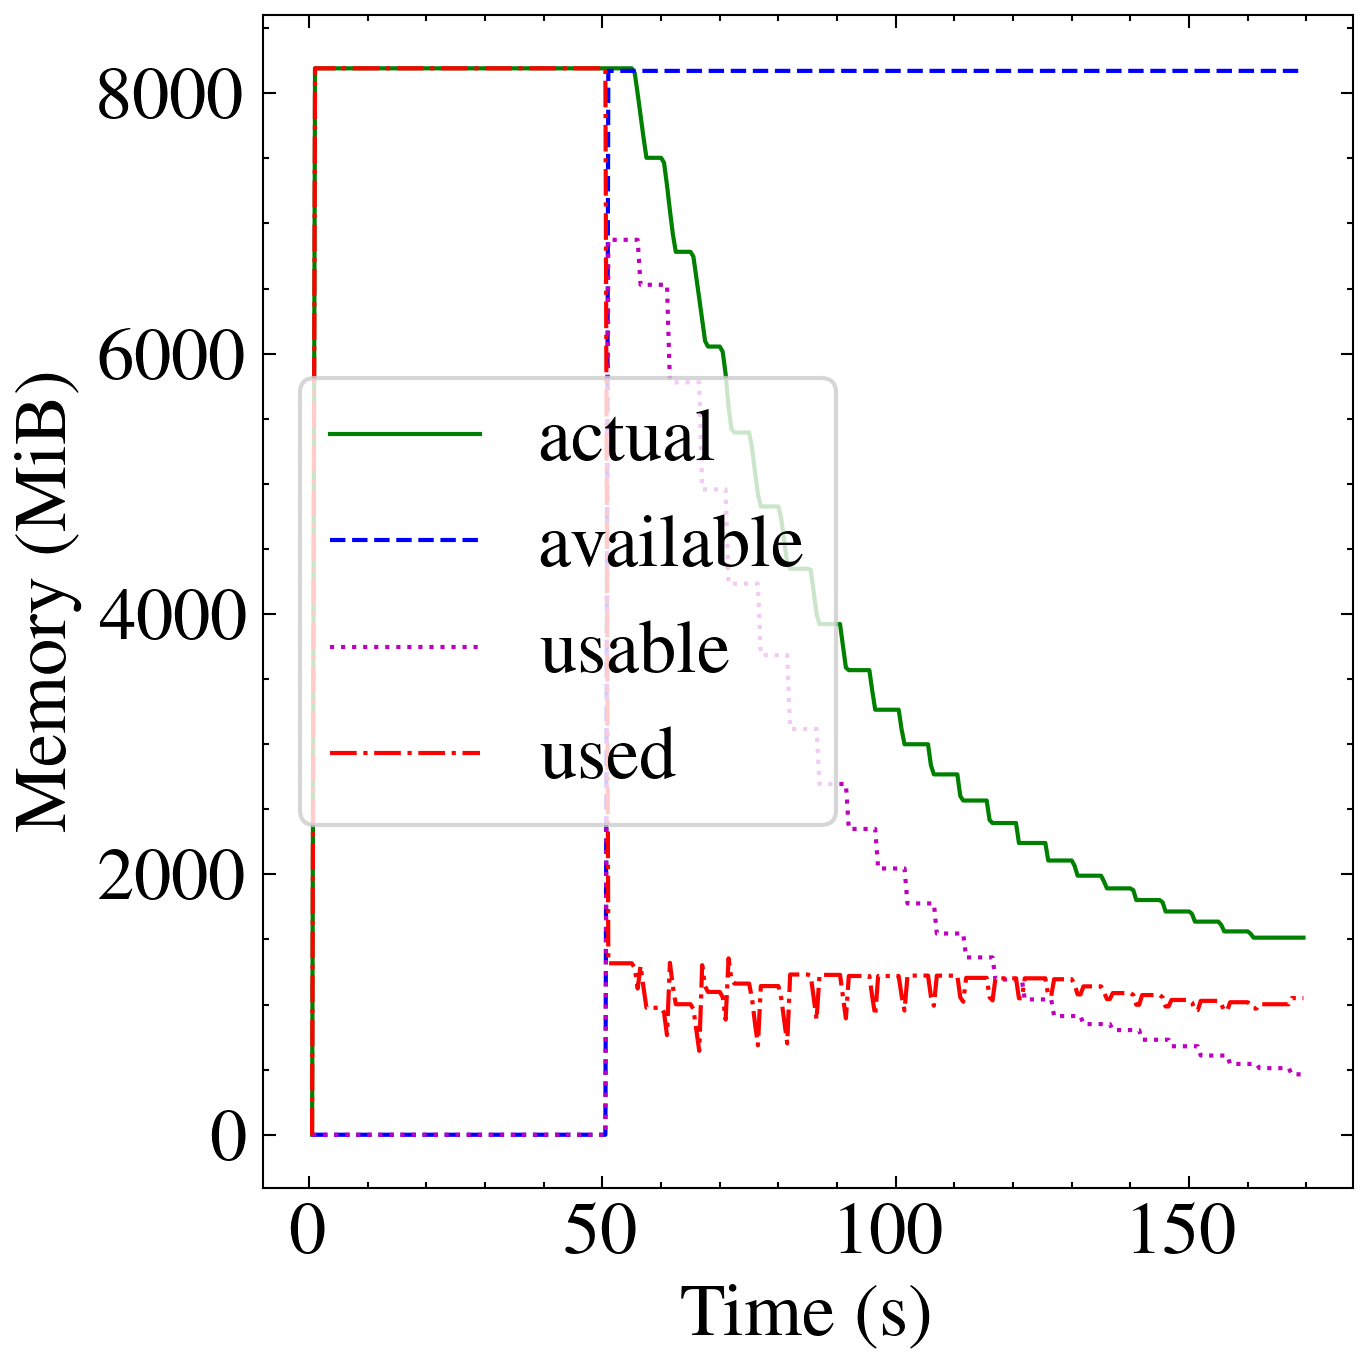

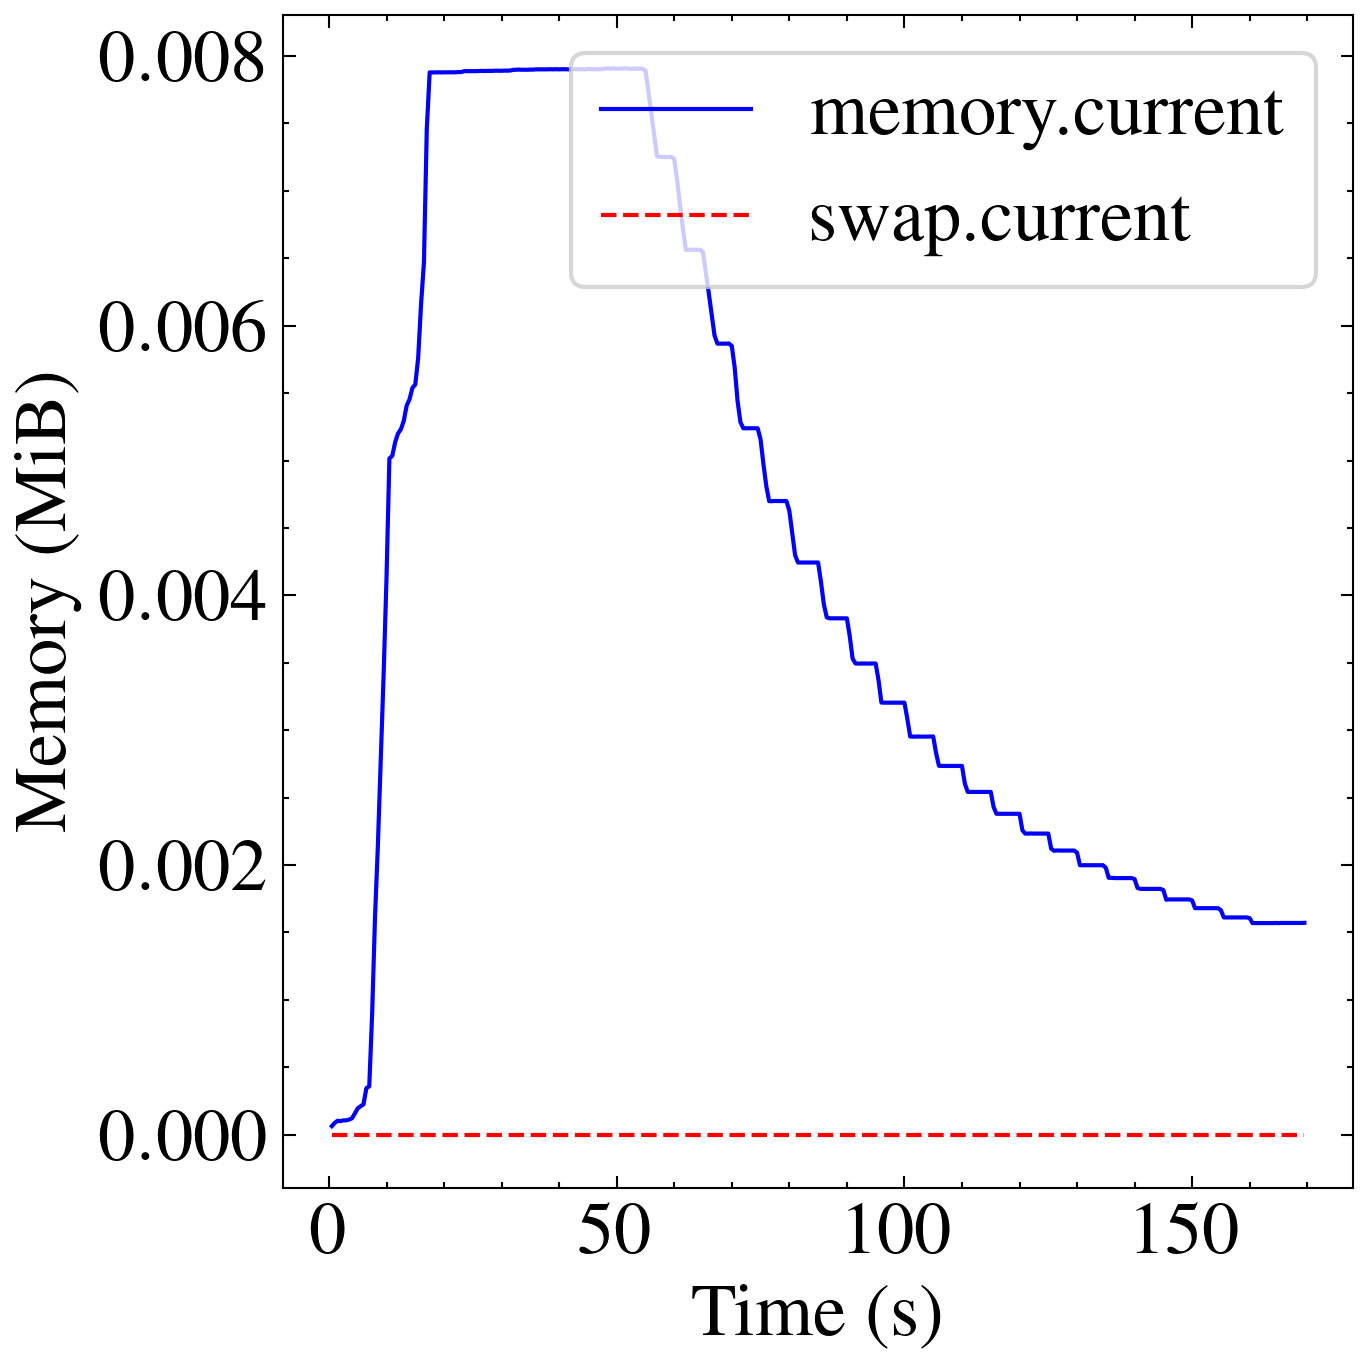

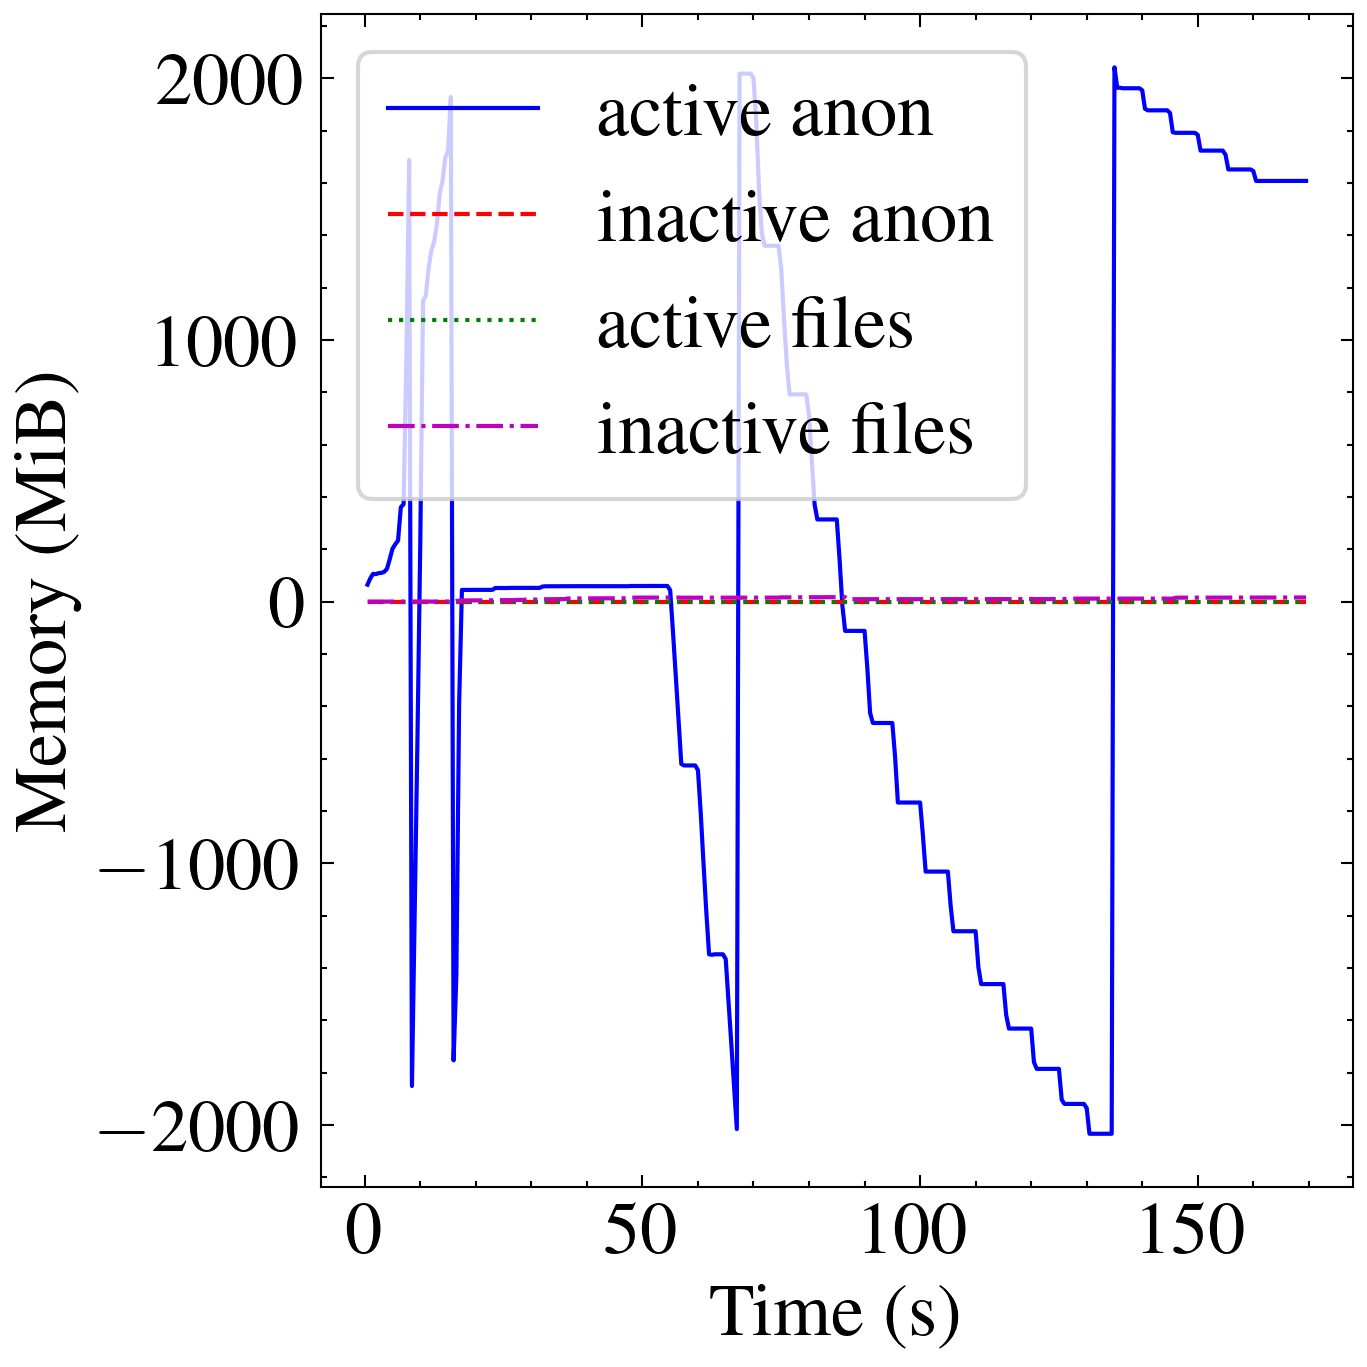

In [25]:
plot_virsh('basic_ballooning_regul')
plot_cgroups('basic_ballooning_regul')
plot_cgroup_lists('basic_ballooning_regul')

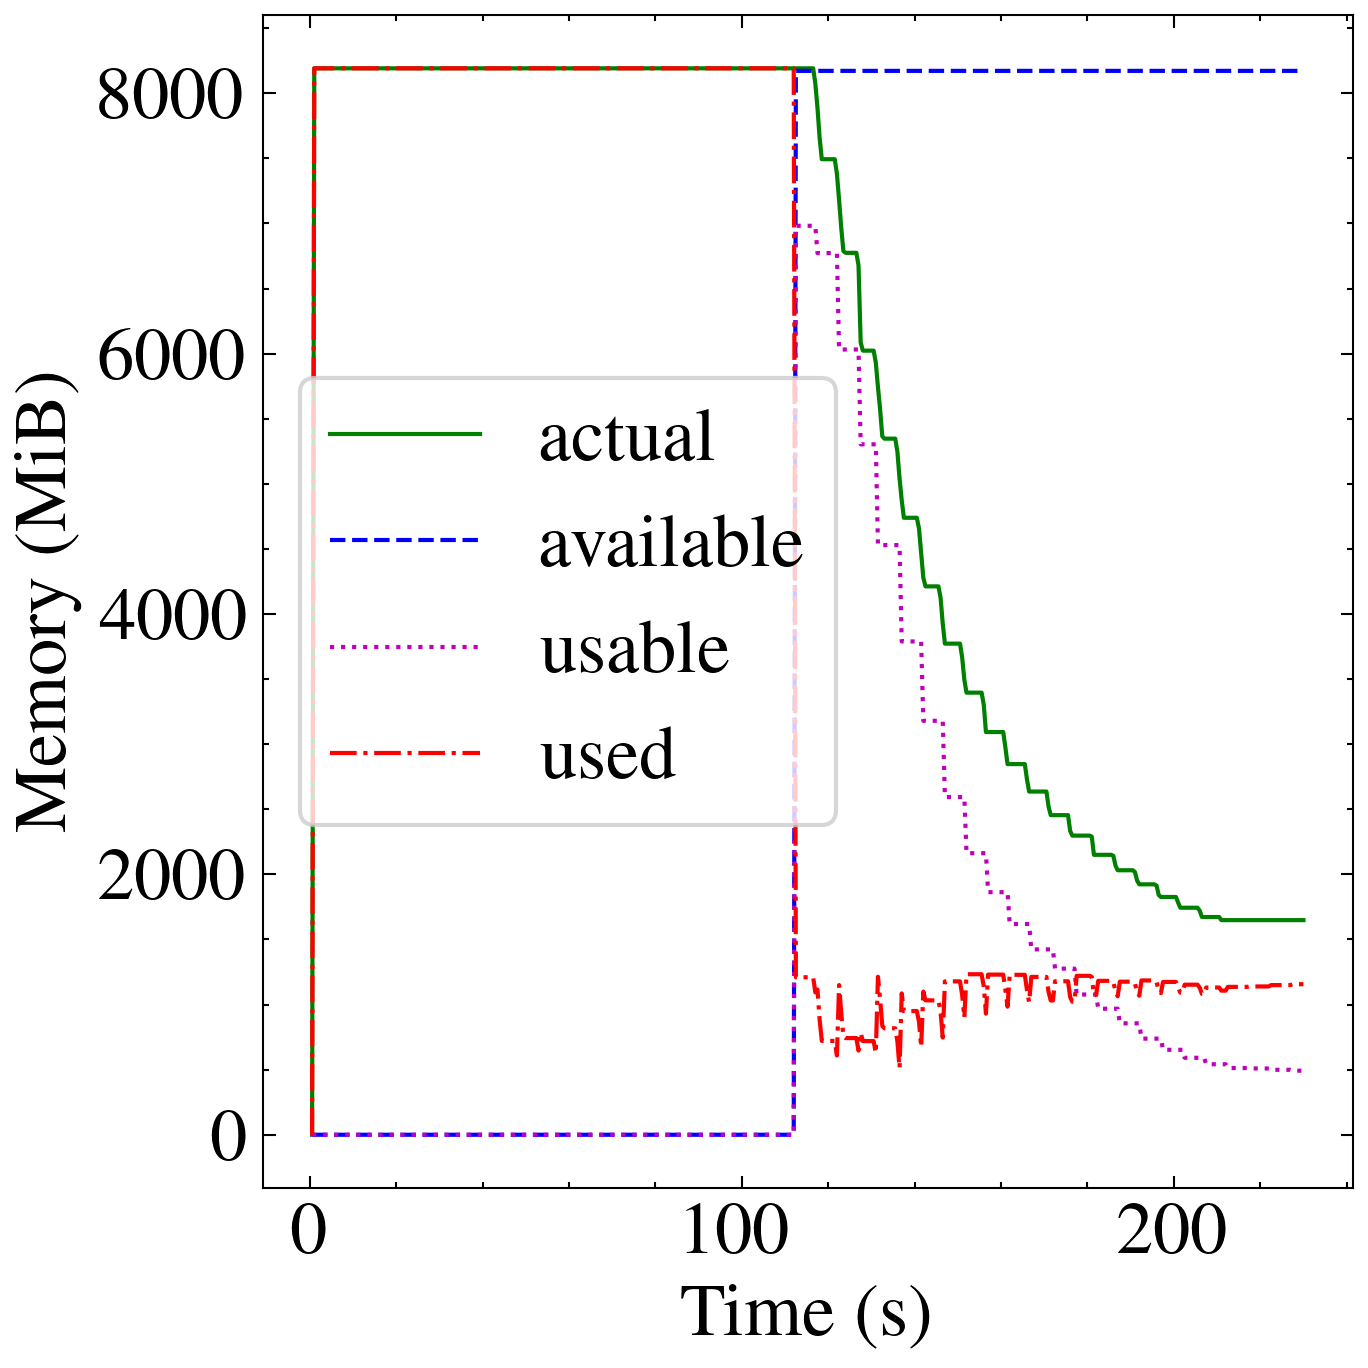

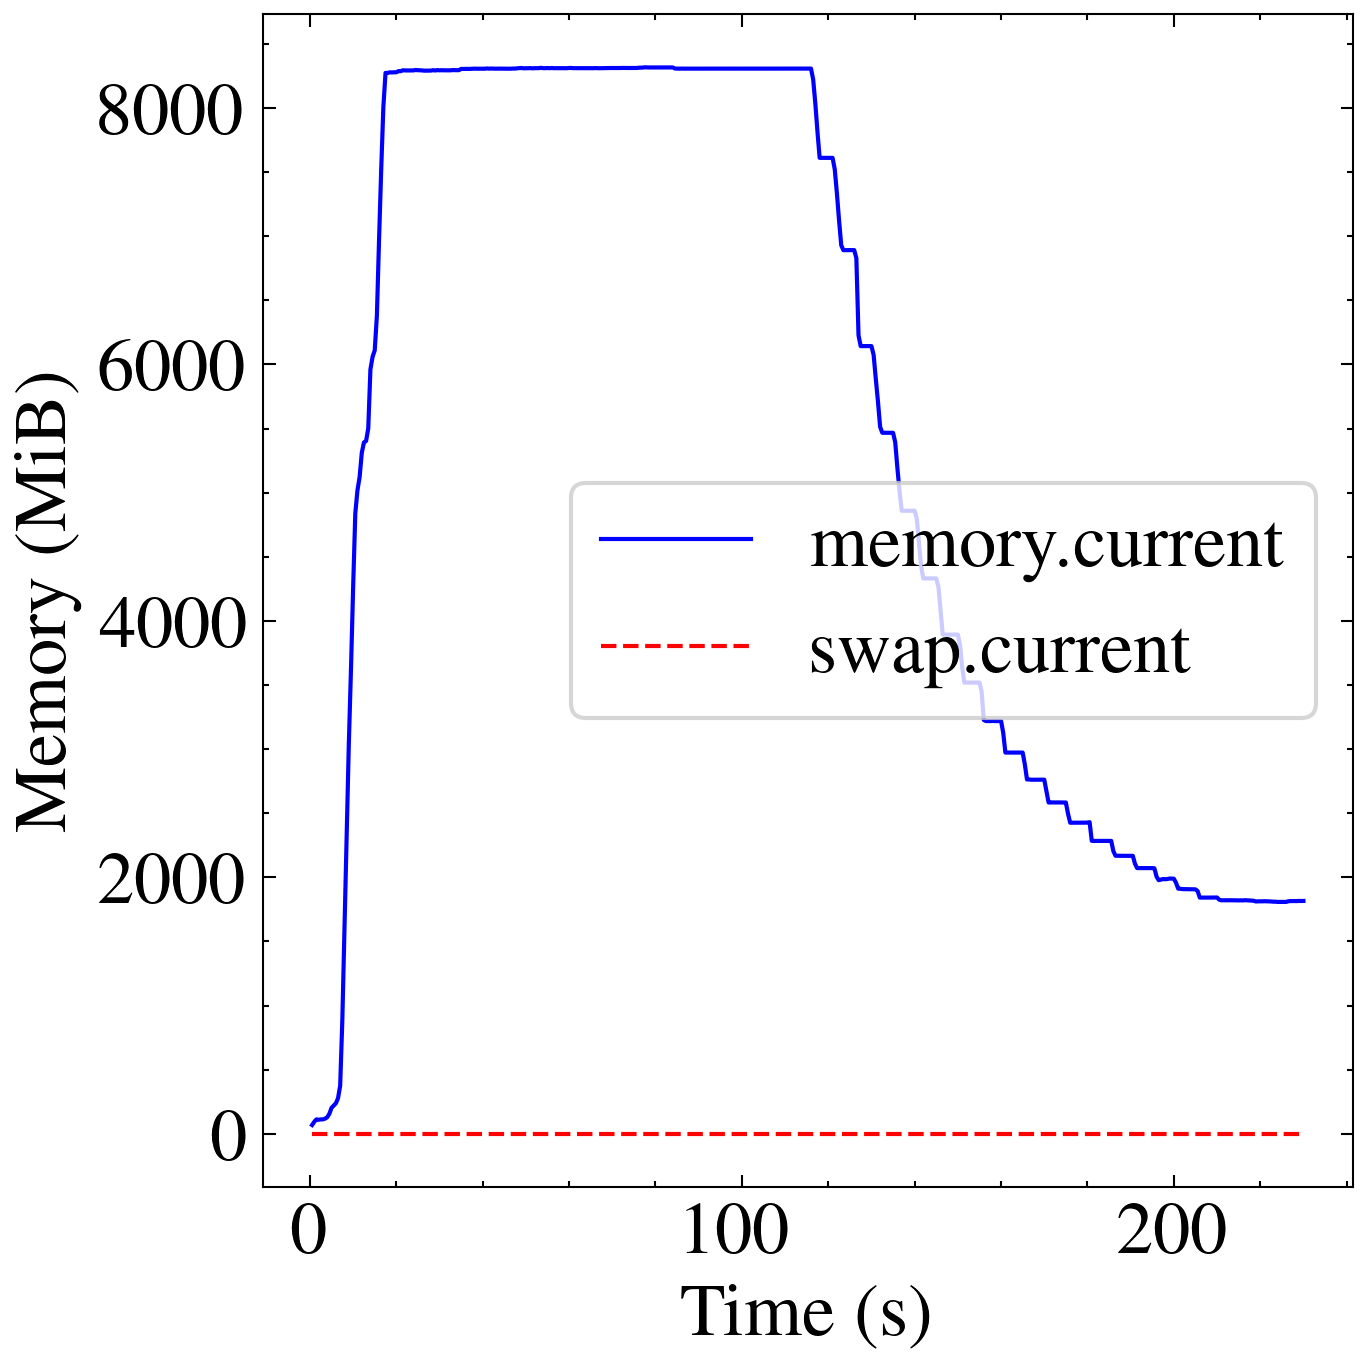

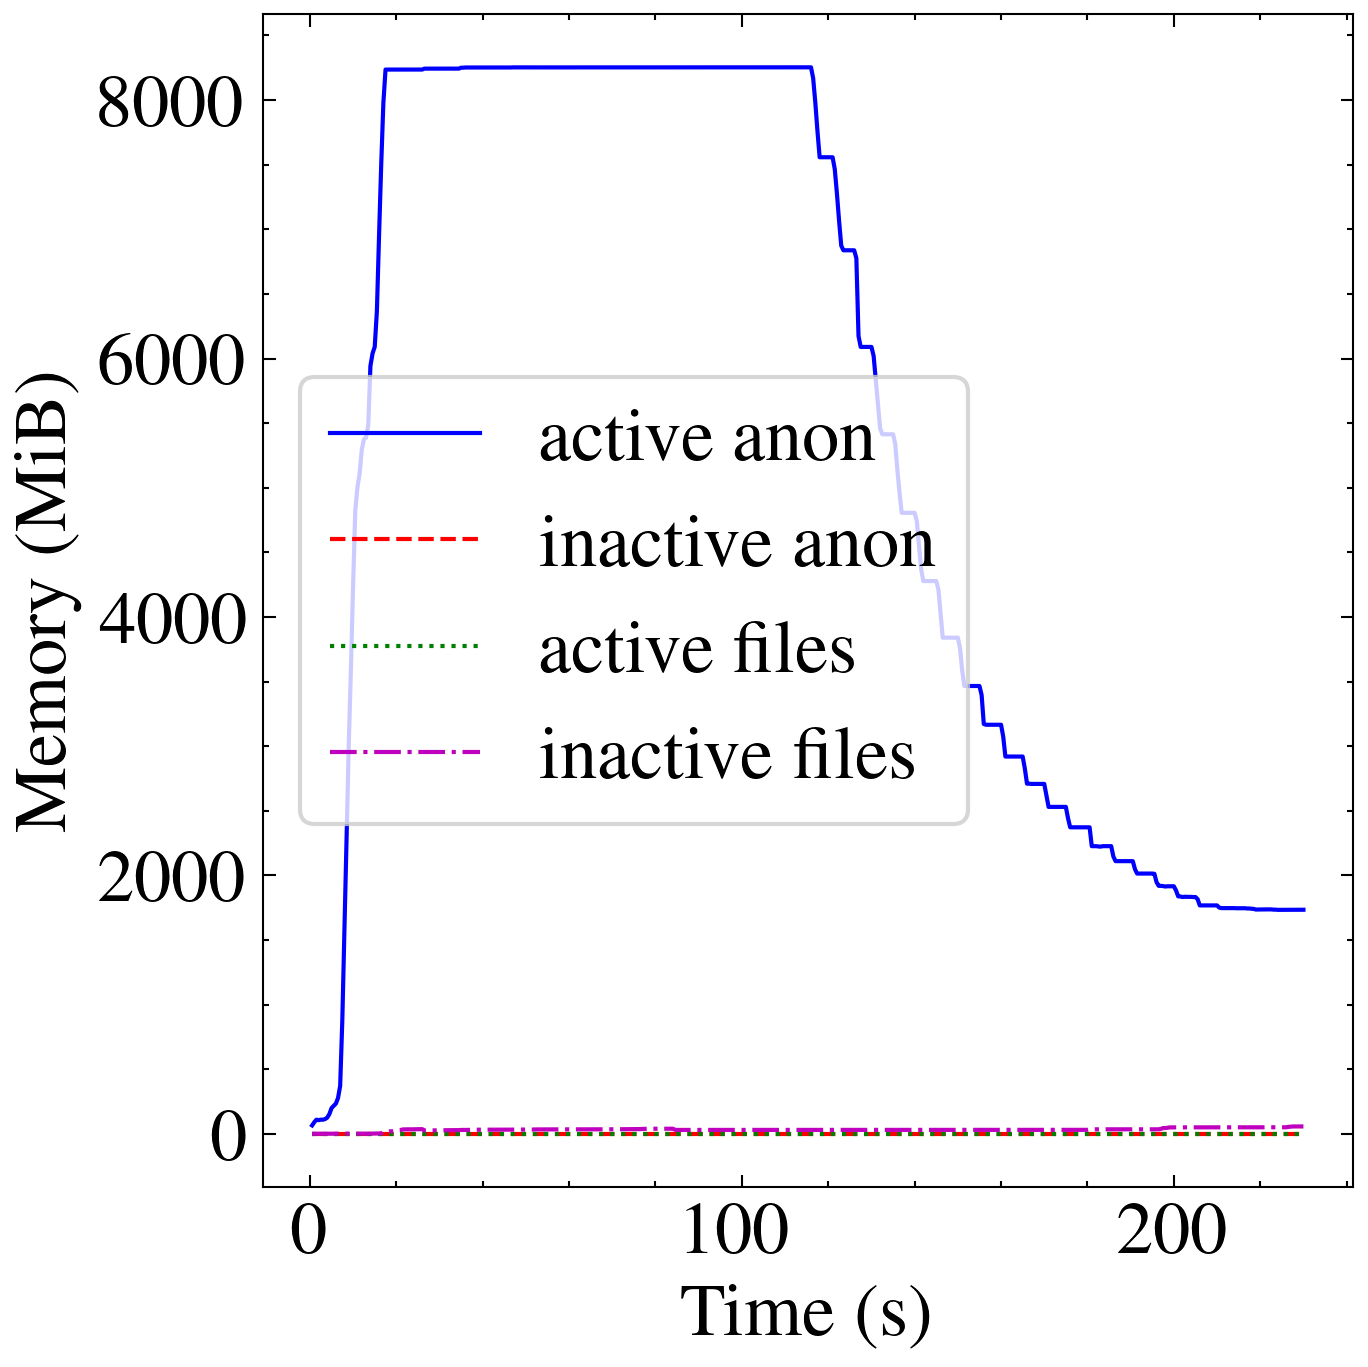

In [26]:
plot_virsh('basic_ballooning_regul_bigint')
plot_cgroups('basic_ballooning_regul_bigint')
plot_cgroup_lists('basic_ballooning_regul_bigint')